1. Install and Imports

In [1]:
! pip install mediapipe==0.10.21 opencv-contrib-python==4.10.0.84 numpy==1.26.4 scipy==1.13.1 matplotlib==3.8.4 protobuf==4.25.3 pandas -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sunil\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import cv2, mediapipe as mp, numpy as np, math, os, csv, time
import pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path
from IPython.display import display
print(cv2.__version__, mp.__version__, np.__version__)


4.11.0 0.10.9 1.26.4


 Config

In [ ]:


datasetRoot   = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\0'
outputDir     = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles'

subjectIds    = None   
cameraNames   = None   
saveVideo     = False

modelComplexity   = 1
minDetectConf     = 0.4
minTrackConf      = 0.4
visibilityThresh  = 0.5
claheClip         = 2.5
claheGrid         = (8, 8)
savgolWindow      = 15   
savgolOrder       = 3

os.makedirs(outputDir, exist_ok=True)

root = Path(datasetRoot)
if not root.exists():
    raise FileNotFoundError(f'Dataset root not found: {datasetRoot}')

if subjectIds is None:
    subjectIds = sorted([d.name for d in root.iterdir() if d.is_dir()])

videoFiles = {}
for sid in subjectIds:
    subjDir = root / sid
    if not subjDir.exists():
        print(f'[WARN] subject {sid}: folder not found, skipping'); continue
    mp4s = sorted(subjDir.glob('*.mp4'))
    if not mp4s:
        print(f'[WARN] subject {sid}: no .mp4 files found, skipping'); continue
    for mp4 in mp4s:
        cam = mp4.stem
        if cameraNames is None or cam in cameraNames:
            videoFiles[(sid, cam)] = str(mp4)

print(f'Subjects: {len(subjectIds)}  |  Videos queued: {len(videoFiles)}')

Subjects: 16  |  Videos queued: 80


Helpers

In [ ]:
mpPose = mp.solutions.pose
_clahe = cv2.createCLAHE(clipLimit=claheClip, tileGridSize=claheGrid)

def enhanceFrame(frame):
    l, a, b = cv2.split(cv2.cvtColor(frame, cv2.COLOR_BGR2LAB))
    return cv2.cvtColor(cv2.merge([_clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

def angle(a, b, c):
    ba = np.array([a[0]-b[0], a[1]-b[1]], dtype=float)
    bc = np.array([c[0]-b[0], c[1]-b[1]], dtype=float)
    n = np.linalg.norm(ba) * np.linalg.norm(bc)
    return math.degrees(math.acos(np.clip(np.dot(ba,bc)/n,-1,1))) if n else 0.0

def lmPx(lm, idx, w, h):
    p = lm[idx]
    return (int(p.x*w), int(p.y*h)) if p.visibility >= visibilityThresh else None

def drawSkeleton(frame, lm, angles, w, h):
    for s,e in [(23,25),(25,27),(24,26),(26,28),(23,24)]:
        ps,pe = lm[s],lm[e]
        if ps.visibility>=visibilityThresh and pe.visibility>=visibilityThresh:
            cv2.line(frame,(int(ps.x*w),int(ps.y*h)),(int(pe.x*w),int(pe.y*h)),(255,165,0),3,cv2.LINE_AA)
    for i in range(23,33):
        p=lm[i]
        if p.visibility>=visibilityThresh:
            cv2.circle(frame,(int(p.x*w),int(p.y*h)),7,(0,255,0),-1,cv2.LINE_AA)
    for i,lbl,key,col in [(25,'LK','L_knee',(100,255,100)),(26,'RK','R_knee',(100,255,100)),
                           (23,'LH','L_hip',(255,200,100)),(24,'RH','R_hip',(255,200,100)),
                           (27,'LA','L_ankle',(200,100,255)),(28,'RA','R_ankle',(200,100,255))]:
        p=lm[i]; v=angles.get(key)
        if p.visibility>=visibilityThresh and v is not None:
            cv2.putText(frame,f'{lbl}:{v:.0f}',(int(p.x*w)+12,int(p.y*h)-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.55,col,2,cv2.LINE_AA)

csvFields = ['subject','camera','frame','timestampMs','timeS','detection',
             'L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle',
             'vis_LK','vis_RK','vis_LA','vis_RA','vis_LH','vis_RH']


ANAT_LIMITS = {
    'L_knee':  (0,   175),
    'R_knee':  (0,   175),
    'L_hip':   (-30, 140),   
    'R_hip':   (-30, 140),
    'L_ankle': (50,  140),
    'R_ankle': (50,  140),
}

def clip_angle(key, val):
    if val is None:
        return None
    lo, hi = ANAT_LIMITS.get(key, (0, 360))
    return float(np.clip(val, lo, hi))

MAX_INTERP_GAP = 5   

def interpolate_with_gap(series, max_gap=MAX_INTERP_GAP):
    s = series.copy().astype(float)
    mask = s.isna()
    if not mask.any():
        return s
    run_id  = mask.ne(mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform('sum')
    s_interp = s.interpolate(method='linear', limit_direction='both')
    s_interp[mask & (run_len > max_gap)] = float('nan')
    return s_interp

VEL_SPIKE_THRESH = 300   # 

def mask_velocity_spikes(series, fps, thresh=VEL_SPIKE_THRESH):
    s   = series.copy().astype(float)
    vel = s.diff().abs() * fps
    s[vel > thresh] = float('nan')
    return s

print('Helpers ready')

Helpers ready


In [1]:
def profileOf(cam):
    c = cam.lower()
    if any(k in c for k in ('left','lft','l_')): return 'left'
    if any(k in c for k in ('right','rgt','r_')): return 'right'
    if any(k in c for k in ('front','fwd','f_','center','ctr')): return 'front'
    return cam

def drawAnglesOnFrame(frame, lm, ang, w, h, profile):
    BONES = [(23,25),(25,27),(24,26),(26,28),(23,24)]
    for s,e in BONES:
        ps,pe = lm[s],lm[e]
        if ps.visibility>=visibilityThresh and pe.visibility>=visibilityThresh:
            cv2.line(frame,(int(ps.x*w),int(ps.y*h)),(int(pe.x*w),int(pe.y*h)),(255,165,0),3,cv2.LINE_AA)
    for i in range(23,33):
        p=lm[i]
        if p.visibility>=visibilityThresh:
            cv2.circle(frame,(int(p.x*w),int(p.y*h)),6,(0,255,120),-1,cv2.LINE_AA)
    joints = [(25,'LK','L_knee',(120,255,120)),(26,'RK','R_knee',(120,255,120)),
              (23,'LH','L_hip',(255,210,80)),(24,'RH','R_hip',(255,210,80)),
              (27,'LA','L_ankle',(180,100,255)),(28,'RA','R_ankle',(180,100,255))]
    for i,lbl,key,col in joints:
        p=lm[i]; v=ang.get(key)
        if p.visibility>=visibilityThresh and v is not None:
            px,py=int(p.x*w),int(p.y*h)
            cv2.putText(frame,f'{lbl}:{v:.0f}deg',(px+10,py-8),
                        cv2.FONT_HERSHEY_SIMPLEX,0.52,col,2,cv2.LINE_AA)
            cv2.circle(frame,(px,py),10,(255,255,0),2,cv2.LINE_AA)
    cv2.putText(frame,f'Profile:{profile}',(10,28),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,220,255),2,cv2.LINE_AA)
    return frame

print('Profile helpers ready')


Profile helpers ready


 Process All Videos

In [6]:
allDfs   = []
skipped  = []
total    = len(videoFiles)

with mpPose.Pose(static_image_mode=False, model_complexity=modelComplexity,
                 smooth_landmarks=True, min_detection_confidence=minDetectConf,
                 min_tracking_confidence=minTrackConf) as pose:

    for idx, ((sid, cam), vidPath) in enumerate(videoFiles.items(), 1):
        if not os.path.exists(vidPath):
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: file not found')
            skipped.append((sid, cam, 'file not found'))
            continue

        cap = cv2.VideoCapture(vidPath)
        if not cap.isOpened():
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: cannot open video')
            skipped.append((sid, cam, 'cannot open'))
            continue

        fpsVid  = cap.get(cv2.CAP_PROP_FPS) or 30.0
        _sw_raw = max(savgolOrder + 2, round(savgolWindow / 30.0 * fpsVid))
        swLocal = _sw_raw if _sw_raw % 2 == 1 else _sw_raw + 1
        totalF  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        vidW    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        vidH    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        subjOut = os.path.join(outputDir, f'subject_{sid}')
        os.makedirs(subjOut, exist_ok=True)

        writer = None
        if saveVideo:
            writer = cv2.VideoWriter(os.path.join(subjOut, f'{cam}_annotated.mp4'),
                                     cv2.VideoWriter_fourcc(*'mp4v'), 30, (vidW, vidH))

        rows, detected, frameIdx, t0 = [], 0, 0, time.time()

        while True:
            ok, frame = cap.read()
            if not ok: break
            frameIdx += 1
            h, w = frame.shape[:2]

            rgb = cv2.cvtColor(enhanceFrame(frame), cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            res = pose.process(rgb)

            row = {'subject':sid,'camera':cam,'frame':frameIdx,
                   'timestampMs':round(frameIdx/fpsVid*1000,1),
                   'timeS':round(frameIdx/fpsVid,4),
                   'detection':0,
                   'L_knee':None,'R_knee':None,'L_hip':None,'R_hip':None,
                   'L_ankle':None,'R_ankle':None,
                   'vis_LK':None,'vis_RK':None,'vis_LA':None,
                   'vis_RA':None,'vis_LH':None,'vis_RH':None}

            if res.pose_landmarks:
                detected += 1
                lm = res.pose_landmarks.landmark
                row.update({'detection':1,
                            'vis_LK':round(lm[25].visibility,3),'vis_RK':round(lm[26].visibility,3),
                            'vis_LA':round(lm[27].visibility,3),'vis_RA':round(lm[28].visibility,3),
                            'vis_LH':round(lm[23].visibility,3),'vis_RH':round(lm[24].visibility,3)})

                LH=lmPx(lm,23,w,h);RH=lmPx(lm,24,w,h);LK=lmPx(lm,25,w,h)
                RK=lmPx(lm,26,w,h);LA=lmPx(lm,27,w,h);RA=lmPx(lm,28,w,h)
                LFI=lmPx(lm,31,w,h);RFI=lmPx(lm,32,w,h)

                ang = {}
                if all([LH,LK,LA]):  ang['L_knee']  = row['L_knee']  = round(clip_angle('L_knee', angle(LH,LK,LA)), 2)
                if all([RH,RK,RA]):  ang['R_knee']  = row['R_knee']  = round(clip_angle('R_knee', angle(RH,RK,RA)), 2)
                # Hip flexion vs. downward vertical
                _vt = np.array([0.0, 1.0])
                if LH and LK:
                    thigh_L = np.array([LK[0]-LH[0], LK[1]-LH[1]], dtype=float)
                    n_L = np.linalg.norm(thigh_L)
                    if n_L > 0:
                        hip_L = math.degrees(math.acos(np.clip(np.dot(thigh_L/n_L, _vt), -1, 1)))
                        ang['L_hip'] = row['L_hip'] = round(clip_angle('L_hip', hip_L), 2)
                if RH and RK:
                    thigh_R = np.array([RK[0]-RH[0], RK[1]-RH[1]], dtype=float)
                    n_R = np.linalg.norm(thigh_R)
                    if n_R > 0:
                        hip_R = math.degrees(math.acos(np.clip(np.dot(thigh_R/n_R, _vt), -1, 1)))
                        ang['R_hip'] = row['R_hip'] = round(clip_angle('R_hip', hip_R), 2)
                if all([LK,LA,LFI]): ang['L_ankle'] = row['L_ankle'] = round(clip_angle('L_ankle', angle(LK,LA,LFI)), 2)
                if all([RK,RA,RFI]): ang['R_ankle'] = row['R_ankle'] = round(clip_angle('R_ankle', angle(RK,RA,RFI)), 2)

                if writer: drawSkeleton(frame, lm, ang, w, h)

            if writer: writer.write(frame)
            rows.append(row)

        cap.release()
        if writer: writer.release()

        if frameIdx == 0:
            print(f'[WARN {idx:>3}/{total}] subject={sid} {cam}: 0 frames read')
            skipped.append((sid, cam, '0 frames read'))
            continue

        dfCam = pd.DataFrame(rows, columns=csvFields)
        for _ac in ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']:
            dfCam[_ac] = mask_velocity_spikes(dfCam[_ac], fpsVid)
            dfCam[_ac] = interpolate_with_gap(dfCam[_ac])
        dfCam.to_csv(os.path.join(subjOut, f'{cam}_angles.csv'), index=False)
        allDfs.append(dfCam)

        print(f'[{idx:>3}/{total}] s={sid} {cam}  {frameIdx}fr  '
              f'det={100*detected/frameIdx:.0f}%  {time.time()-t0:.1f}s')

if allDfs:
    merged = pd.concat(allDfs, ignore_index=True)
    merged.to_csv(os.path.join(outputDir,'ALL_subjects_angles.csv'), index=False)
    print(f'\nMerged CSV: {len(merged)} rows')

if skipped:
    print(f'\nSkipped ({len(skipped)}):')
    for s in skipped: print(f'  subject={s[0]} {s[1]}: {s[2]}')

print('Done.')

[  1/80] s=01 cam0  630fr  det=100%  48.5s
[  2/80] s=01 cam1  630fr  det=100%  49.6s
[  3/80] s=01 cam2  630fr  det=100%  50.7s
[  4/80] s=01 cam3  630fr  det=100%  49.1s
[  5/80] s=01 cam4  630fr  det=100%  47.2s
[  6/80] s=02 cam0  917fr  det=100%  68.6s
[  7/80] s=02 cam1  917fr  det=100%  68.2s
[  8/80] s=02 cam2  917fr  det=100%  68.0s
[  9/80] s=02 cam3  917fr  det=100%  68.6s
[ 10/80] s=02 cam4  916fr  det=100%  68.6s
[ 11/80] s=03 cam0  794fr  det=94%  59.2s
[ 12/80] s=03 cam1  794fr  det=100%  59.7s
[ 13/80] s=03 cam2  794fr  det=100%  60.1s
[ 14/80] s=03 cam3  794fr  det=100%  61.0s
[ 15/80] s=03 cam4  794fr  det=100%  59.6s
[ 16/80] s=04 cam0  1146fr  det=100%  87.0s
[ 17/80] s=04 cam1  1146fr  det=100%  86.8s
[ 18/80] s=04 cam2  1146fr  det=100%  86.5s
[ 19/80] s=04 cam3  1146fr  det=100%  87.4s
[ 20/80] s=04 cam4  1146fr  det=100%  88.5s
[ 21/80] s=05 cam0  687fr  det=100%  53.0s
[ 22/80] s=05 cam1  687fr  det=100%  52.4s
[ 23/80] s=05 cam2  687fr  det=100%  51.6s
[ 24/80

Sample Frames

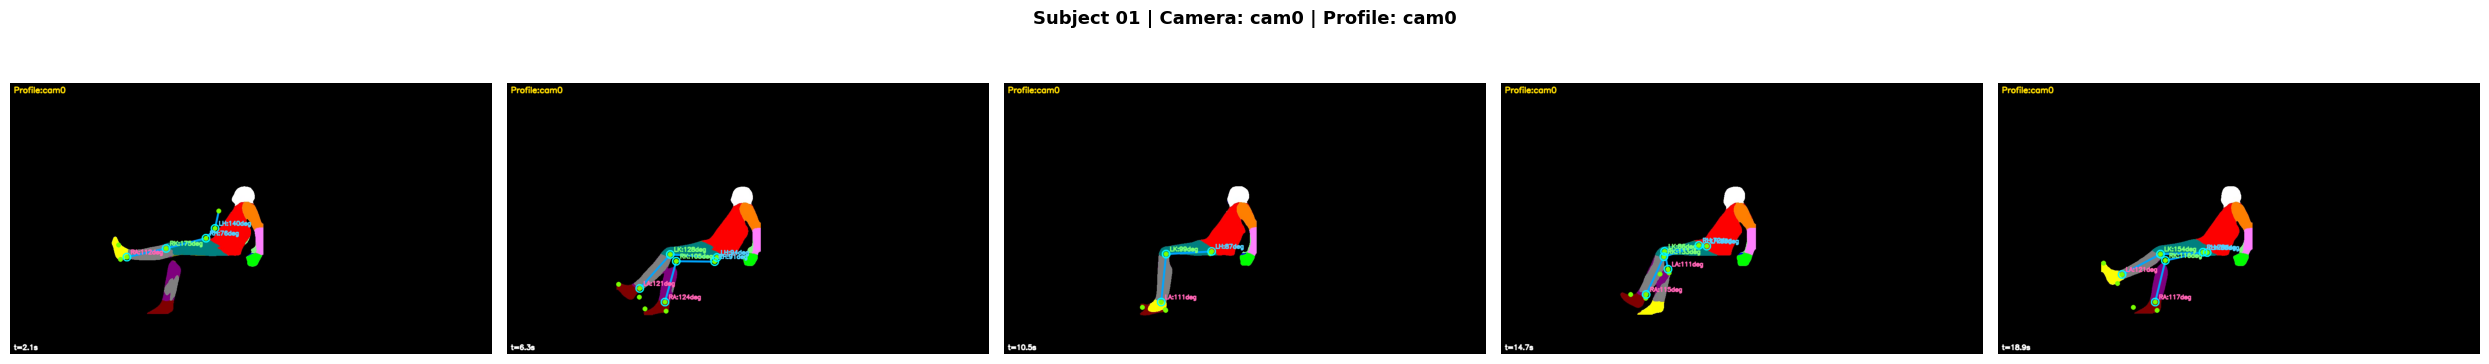

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frames_cam0.png


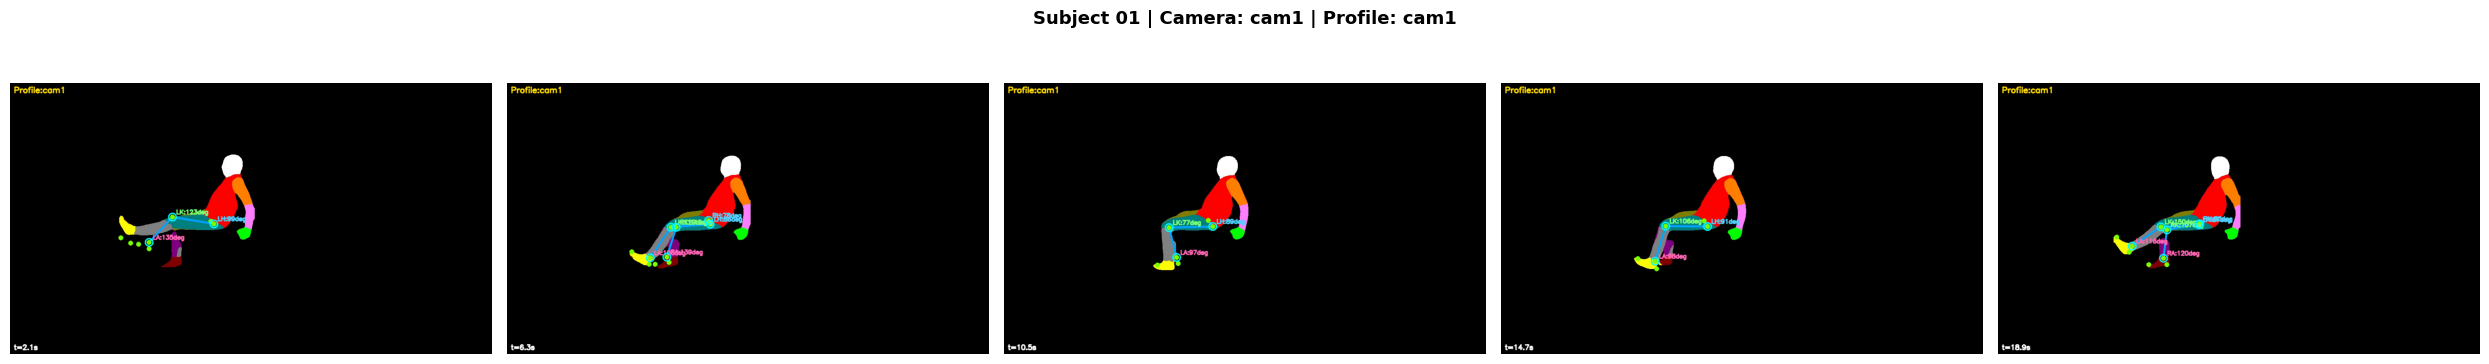

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frames_cam1.png


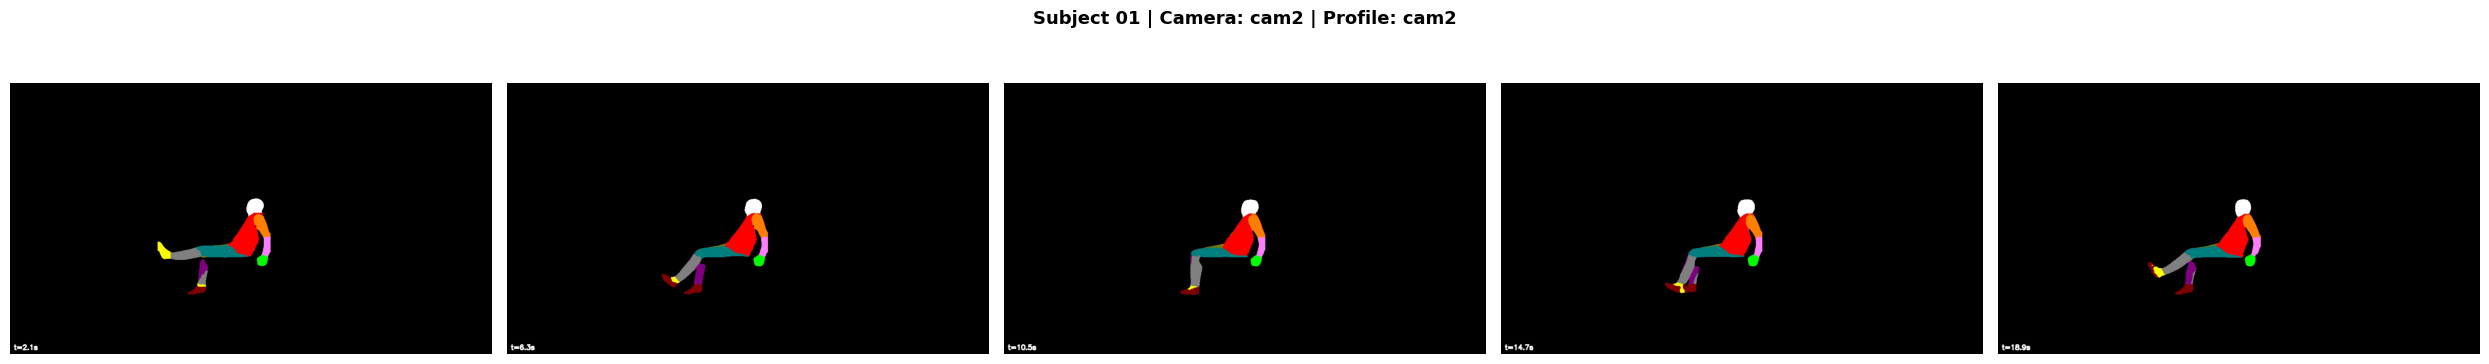

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frames_cam2.png


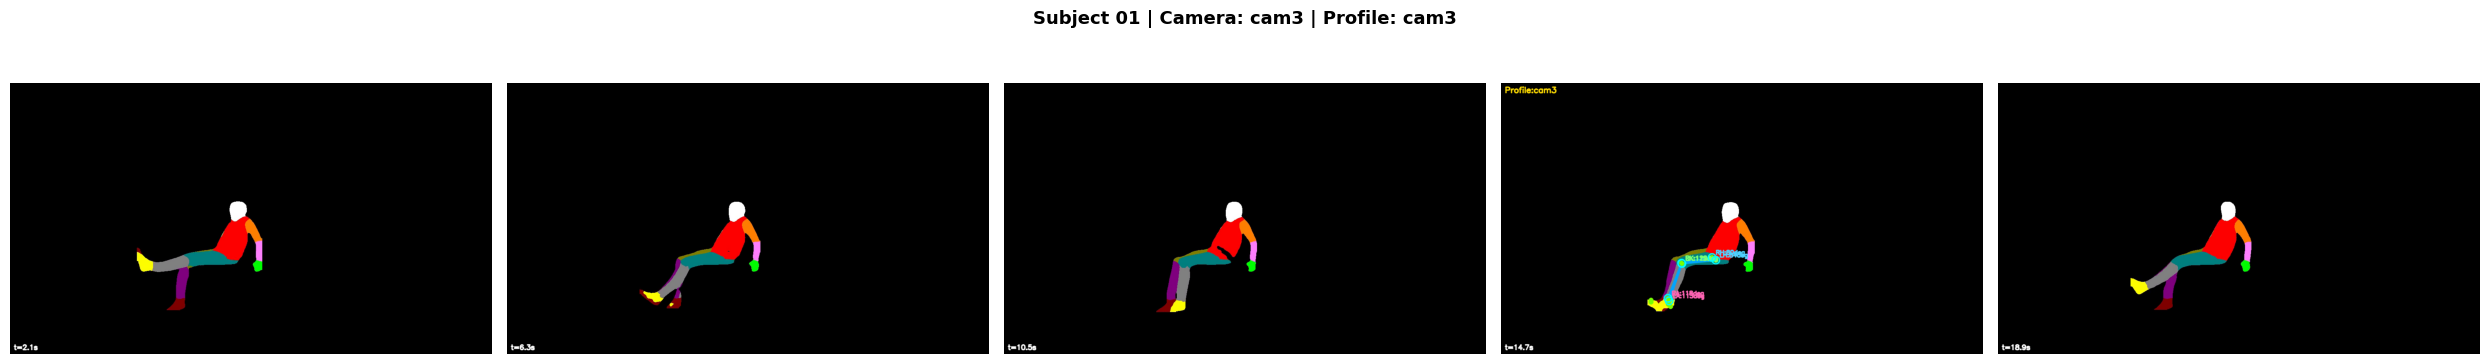

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frames_cam3.png


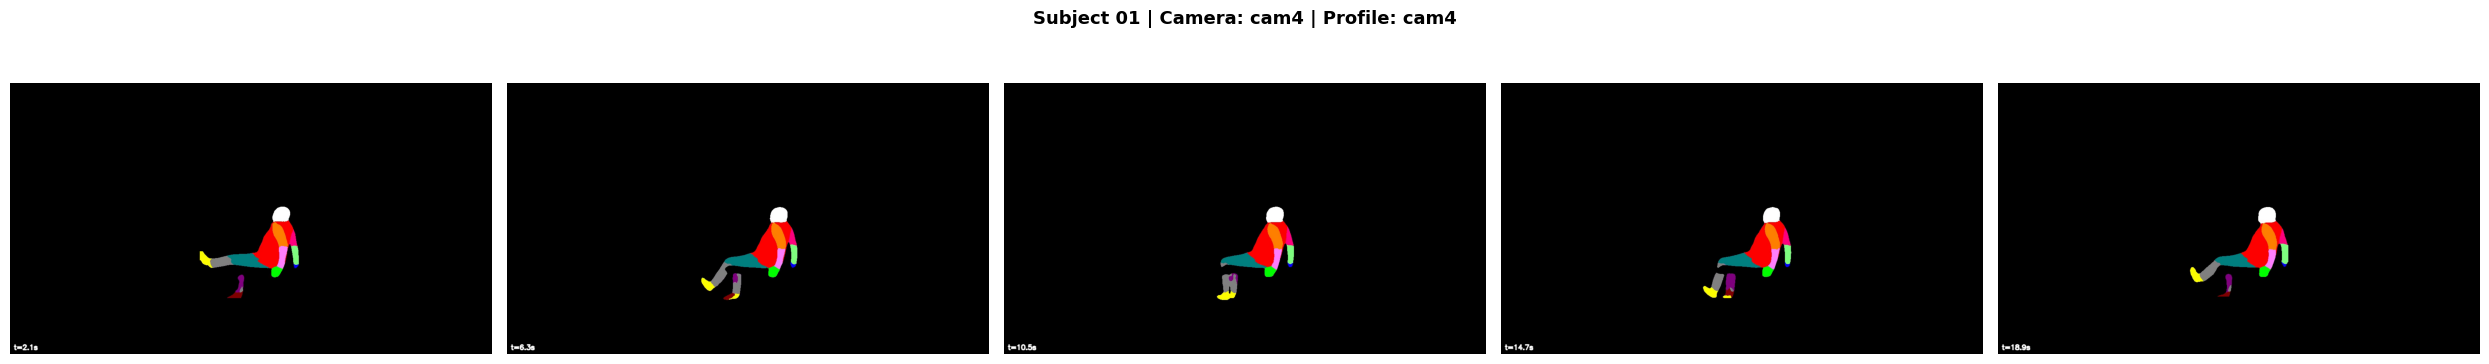

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frames_cam4.png


In [7]:
sidQa   = subjectIds[0]
camsQa  = [(s,c) for (s,c) in videoFiles if s == sidQa]
SAMPLE_POINTS = [0.1, 0.3, 0.5, 0.7, 0.9]   

with mpPose.Pose(static_image_mode=True, model_complexity=modelComplexity,
                 min_detection_confidence=minDetectConf) as poseS:
    for sid, cam in camsQa:
        profile = profileOf(cam)
        cap     = cv2.VideoCapture(videoFiles[(sid,cam)])
        nf      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames  = []
        for frac in SAMPLE_POINTS:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(nf*frac))
            ok, frm = cap.read()
            if not ok: continue
            h,w = frm.shape[:2]
            res = poseS.process(cv2.cvtColor(enhanceFrame(frm), cv2.COLOR_BGR2RGB))
            ang = {}
            if res.pose_landmarks:
                lm = res.pose_landmarks.landmark
                def _p(i): p=lm[i]; return (int(p.x*w),int(p.y*h)) if p.visibility>=visibilityThresh else None
                LH,RH,LK,RK,LA,RA=_p(23),_p(24),_p(25),_p(26),_p(27),_p(28)
                LFI,RFI=_p(31),_p(32)
                if all([LH,LK,LA]):  ang['L_knee']=clip_angle('L_knee',angle(LH,LK,LA))
                if all([RH,RK,RA]):  ang['R_knee']=clip_angle('R_knee',angle(RH,RK,RA))
                if LH and LK:
                    th=np.array([LK[0]-LH[0],LK[1]-LH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['L_hip']=clip_angle('L_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1))))
                if RH and RK:
                    th=np.array([RK[0]-RH[0],RK[1]-RH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['R_hip']=clip_angle('R_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1))))
                if all([LK,LA,LFI]): ang['L_ankle']=clip_angle('L_ankle',angle(LK,LA,LFI))
                if all([RK,RA,RFI]): ang['R_ankle']=clip_angle('R_ankle',angle(RK,RA,RFI))
                drawAnglesOnFrame(frm, lm, ang, w, h, profile)
            ts = round(nf*frac/cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) else 0, 1)
            cv2.putText(frm,f't={ts}s',(10,h-12),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2,cv2.LINE_AA)
            frames.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
        cap.release()
        if not frames: continue
        n  = len(frames)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
        if n==1: axes=[axes]
        fig.suptitle(f'Subject {sid} | Camera: {cam} | Profile: {profile}', fontsize=13, fontweight='bold')
        for ax, img in zip(axes, frames):
            ax.imshow(img); ax.axis('off')
        plt.tight_layout()
        out = os.path.join(outputDir, f'subject_{sid}', f'frames_{cam}.png')
        plt.savefig(out, dpi=110, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out}')


TimeSeries 

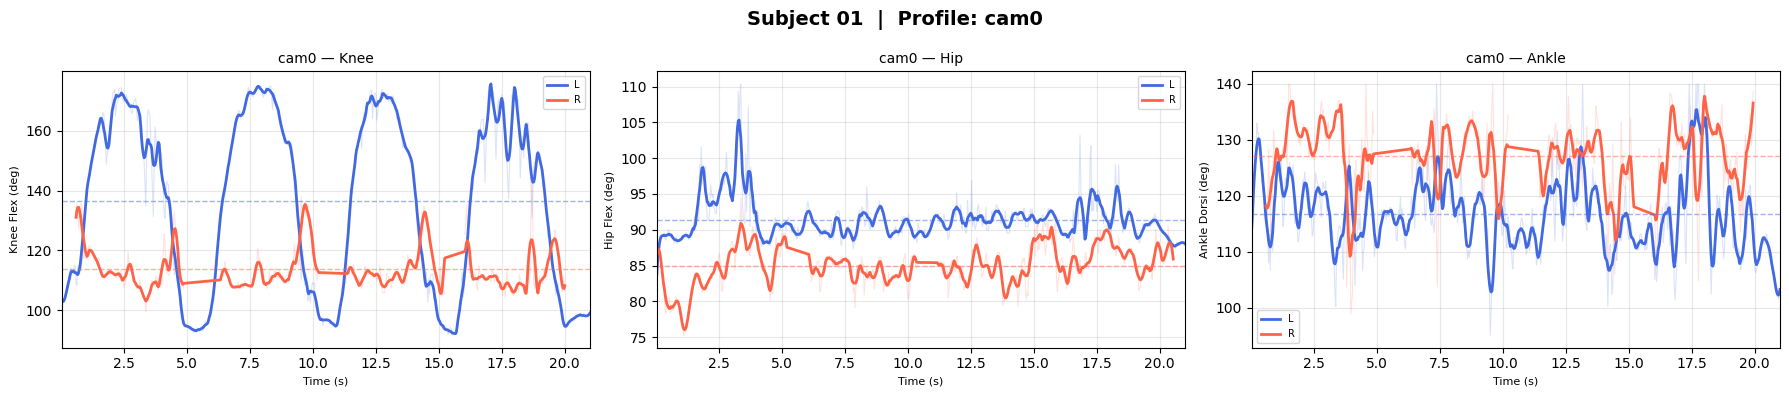

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\ts_01_cam0.png


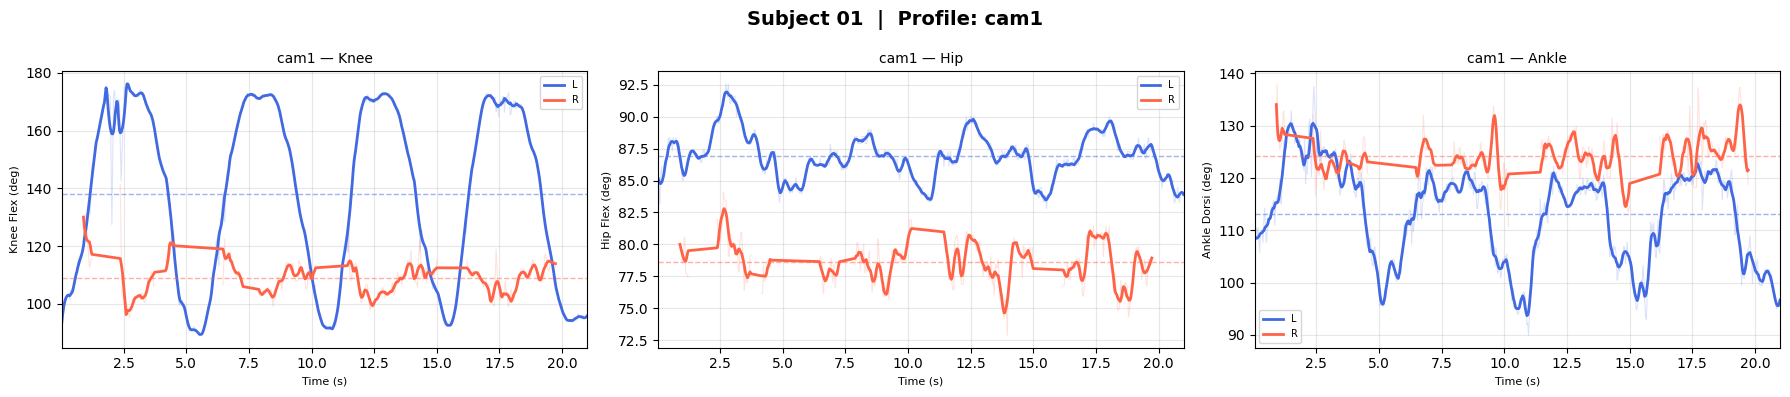

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\ts_01_cam1.png


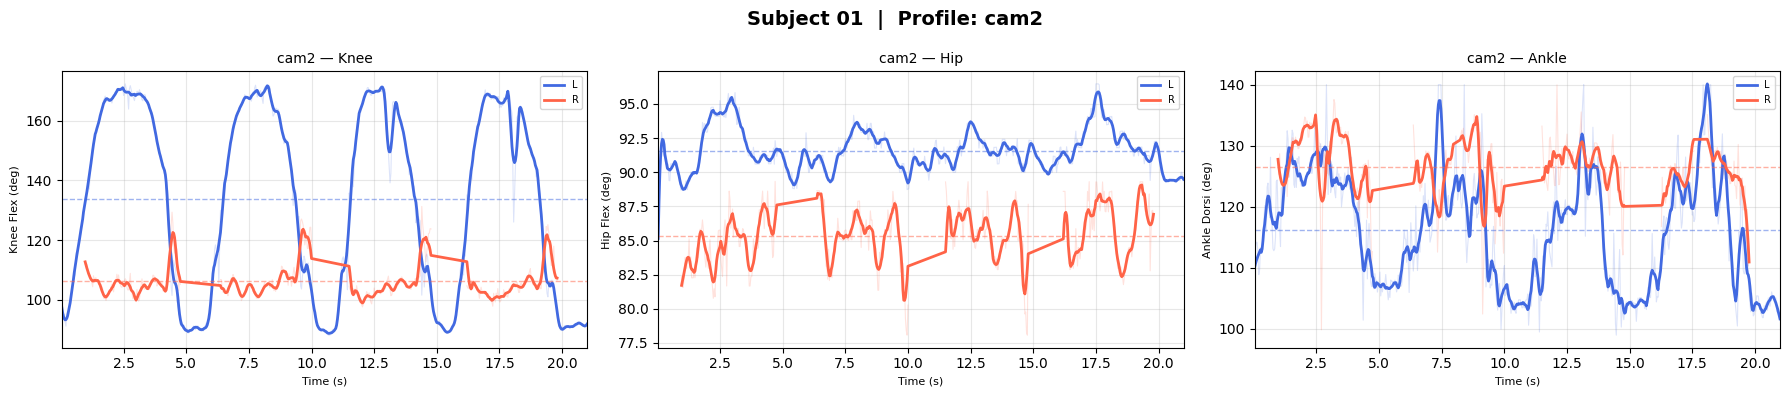

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\ts_01_cam2.png


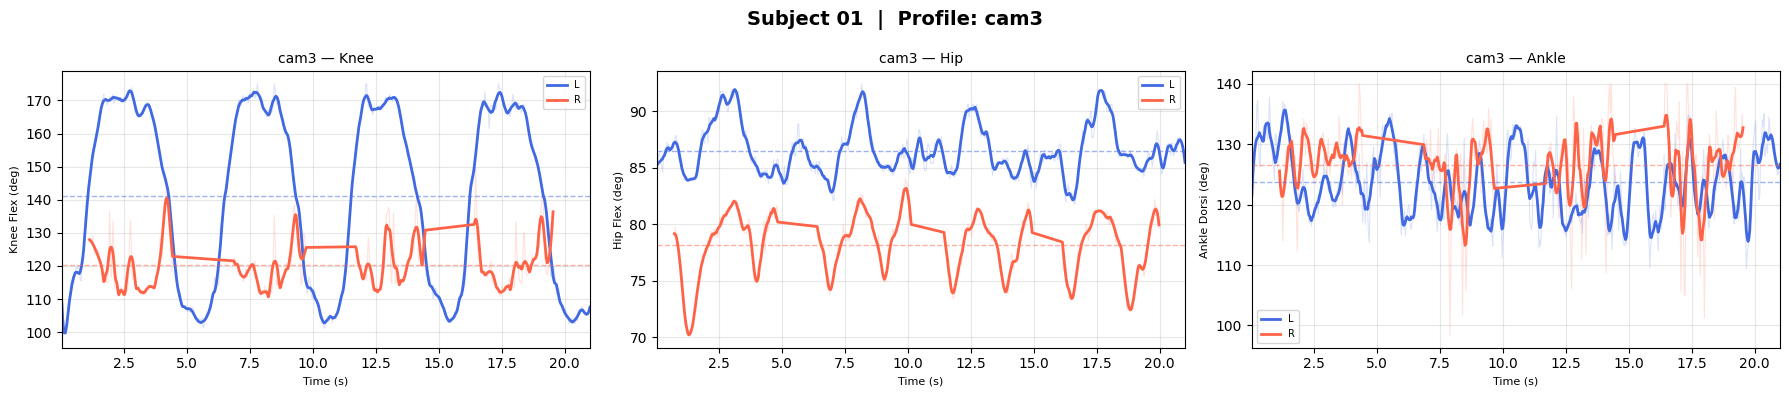

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\ts_01_cam3.png


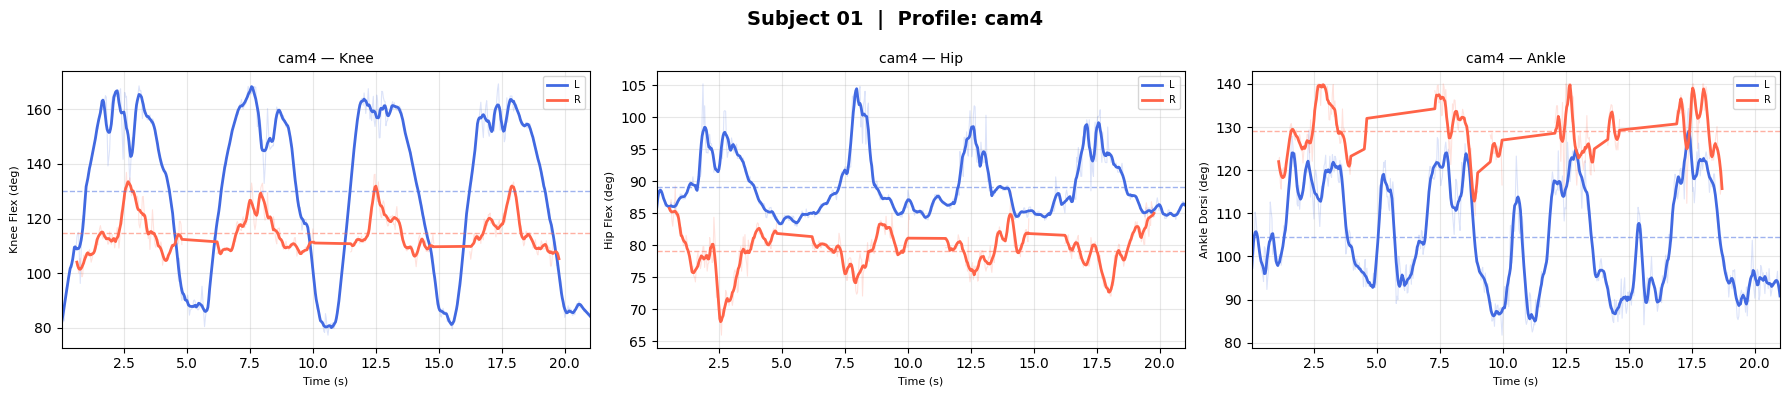

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\ts_01_cam4.png


In [8]:
sidPlot  = subjectIds[0]
dfsSubj  = [df for df in allDfs if df['subject'].iloc[0] == sidPlot]
aPairs   = [('L_knee','R_knee','Knee Flex (deg)'),
             ('L_hip','R_hip','Hip Flex (deg)'),
             ('L_ankle','R_ankle','Ankle Dorsi (deg)')]

profileGroups = {}
for df in dfsSubj:
    p = profileOf(df['camera'].iloc[0])
    profileGroups.setdefault(p, []).append(df)

for profile, dfs in profileGroups.items():
    nC = len(dfs)
    fig, axes = plt.subplots(nC, 3, figsize=(18, 4*nC))
    if nC==1: axes=[axes]
    fig.suptitle(f'Subject {sidPlot}  |  Profile: {profile}', fontsize=14, fontweight='bold')
    for ri, df in enumerate(dfs):
        t = df['timeS']
        for ci, (lc,rc,yl) in enumerate(aPairs):
            ax = axes[ri][ci]
            fps_df  = 1.0 / df['timeS'].diff().median() if df['timeS'].diff().median() > 0 else 30.0
            _sw_r   = max(savgolOrder+2, round(savgolWindow/30.0*fps_df))
            sw_plot = _sw_r if _sw_r%2==1 else _sw_r+1
            lr = interpolate_with_gap(df[lc]); rr = interpolate_with_gap(df[rc])
            ls = savgol_filter(lr.dropna(),sw_plot,savgolOrder) if lr.notna().sum()>=sw_plot else lr.dropna().values
            rs = savgol_filter(rr.dropna(),sw_plot,savgolOrder) if rr.notna().sum()>=sw_plot else rr.dropna().values
            t_l = df.loc[lr.notna(),'timeS']; t_r = df.loc[rr.notna(),'timeS']
            ax.plot(df['timeS'],lr,alpha=0.18,color='royalblue',lw=0.8)
            ax.plot(df['timeS'],rr,alpha=0.18,color='tomato',lw=0.8)
            ax.plot(t_l,ls,color='royalblue',lw=2,label='L')
            ax.plot(t_r,rs,color='tomato',lw=2,label='R')
            if len(ls): ax.axhline(ls.mean(),color='royalblue',lw=1,ls='--',alpha=0.5)
            if len(rs): ax.axhline(rs.mean(),color='tomato',lw=1,ls='--',alpha=0.5)
            ax.set_title(f"{df['camera'].iloc[0]} — {yl.split(' ')[0]}",fontsize=10)
            ax.set_xlabel('Time (s)',fontsize=8); ax.set_ylabel(yl,fontsize=8)
            ax.legend(fontsize=7); ax.grid(True,alpha=0.3); ax.set_xlim(t.min(),t.max())
    plt.tight_layout()
    out = os.path.join(outputDir, f'ts_{sidPlot}_{profile}.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


Frame Strip w Angles Overlay

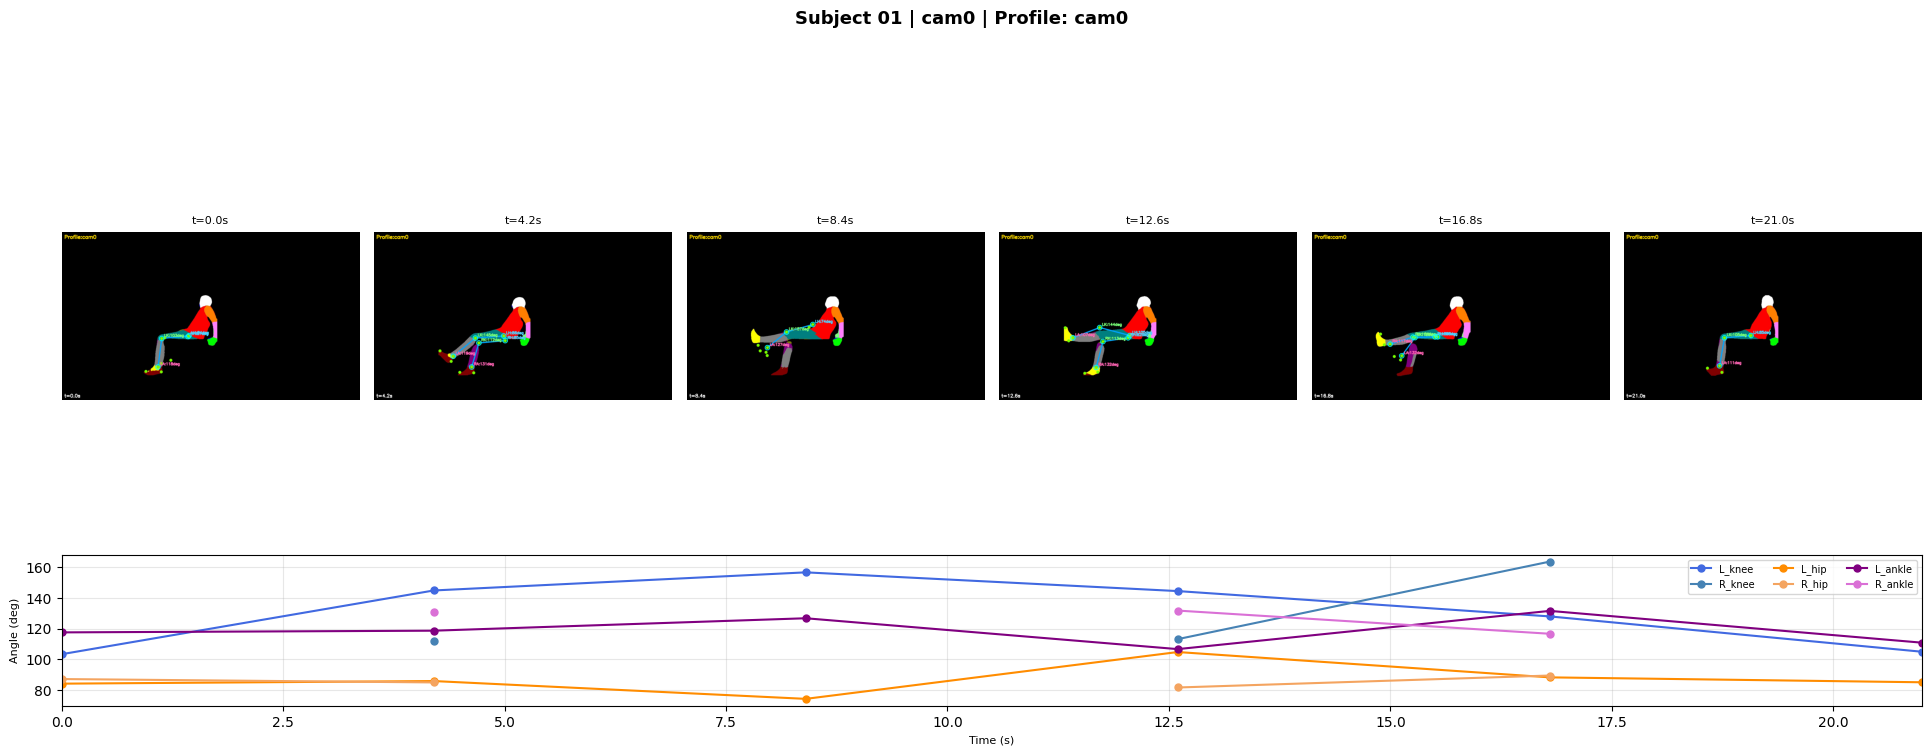

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frame_angles_cam0.png


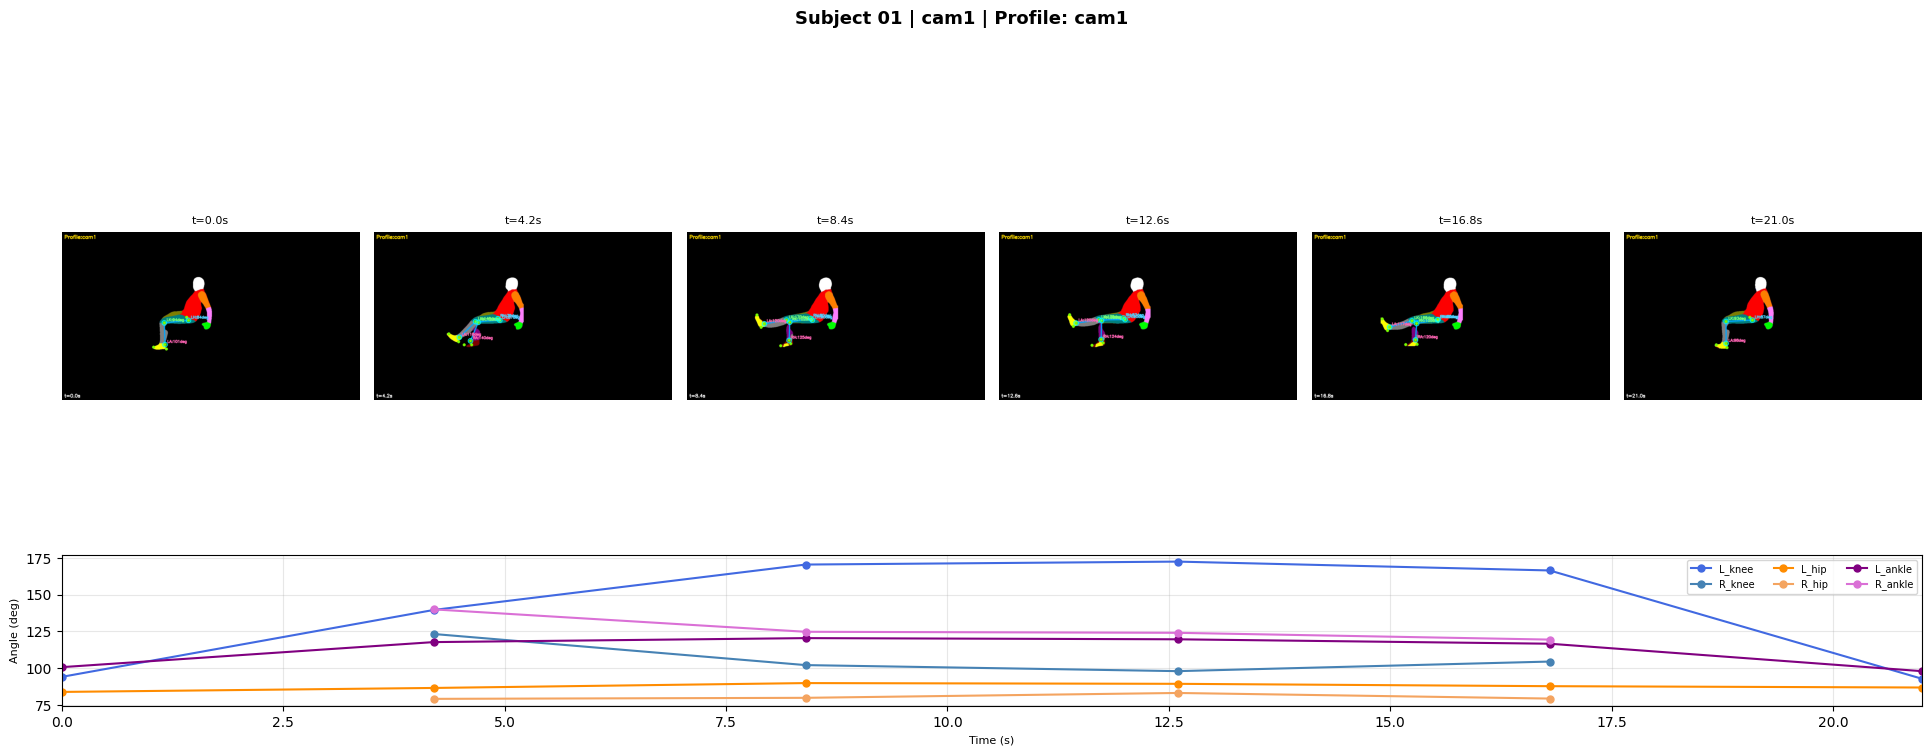

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frame_angles_cam1.png


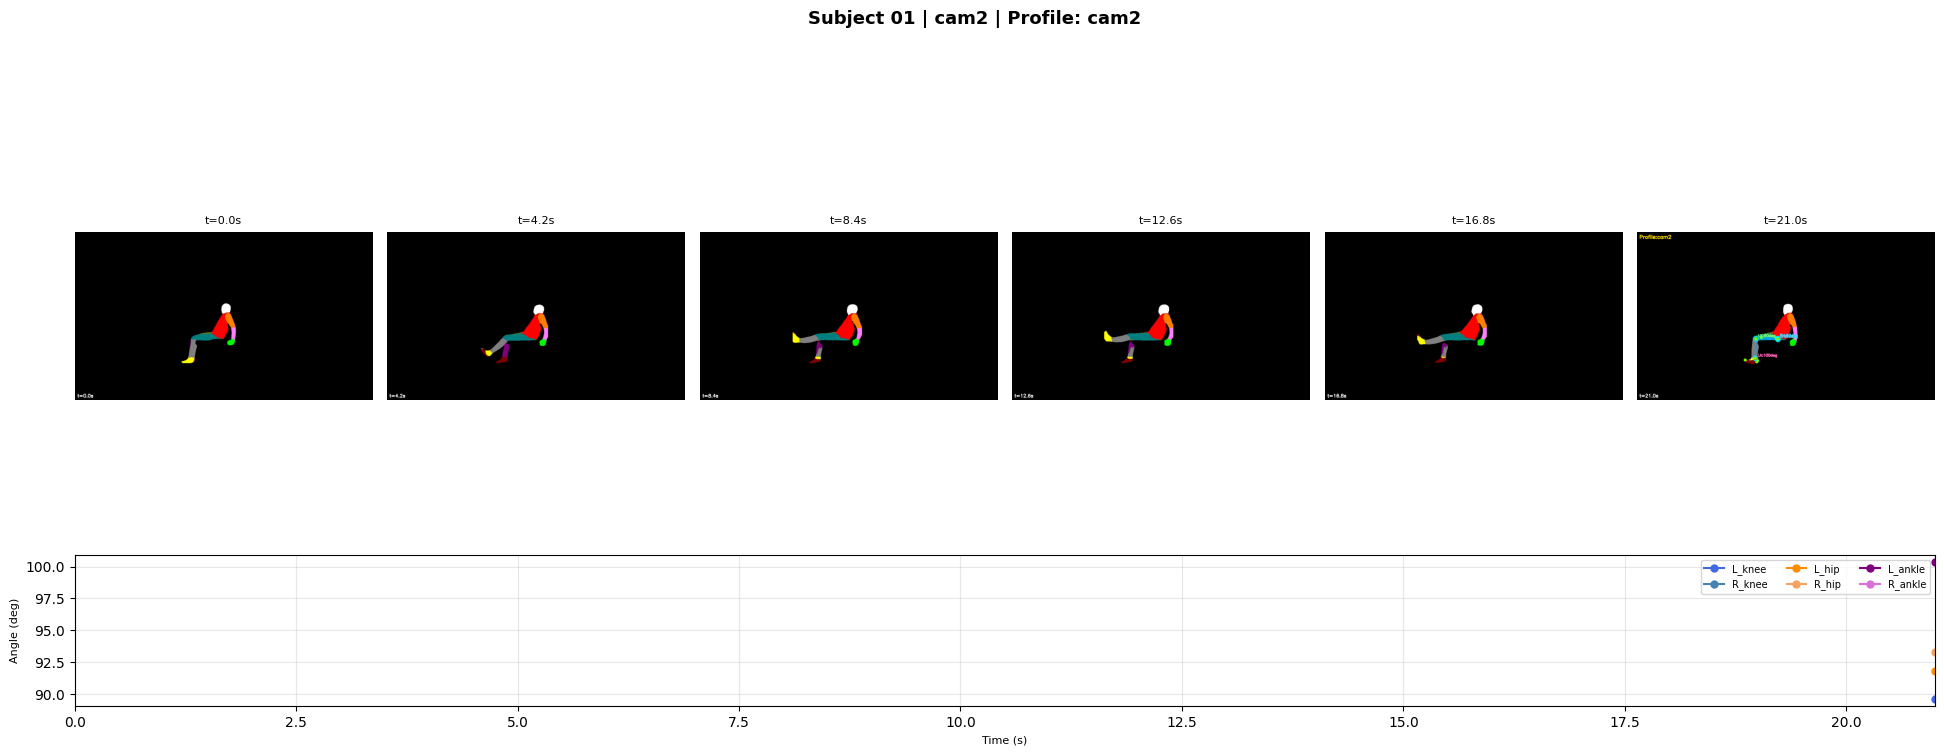

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frame_angles_cam2.png


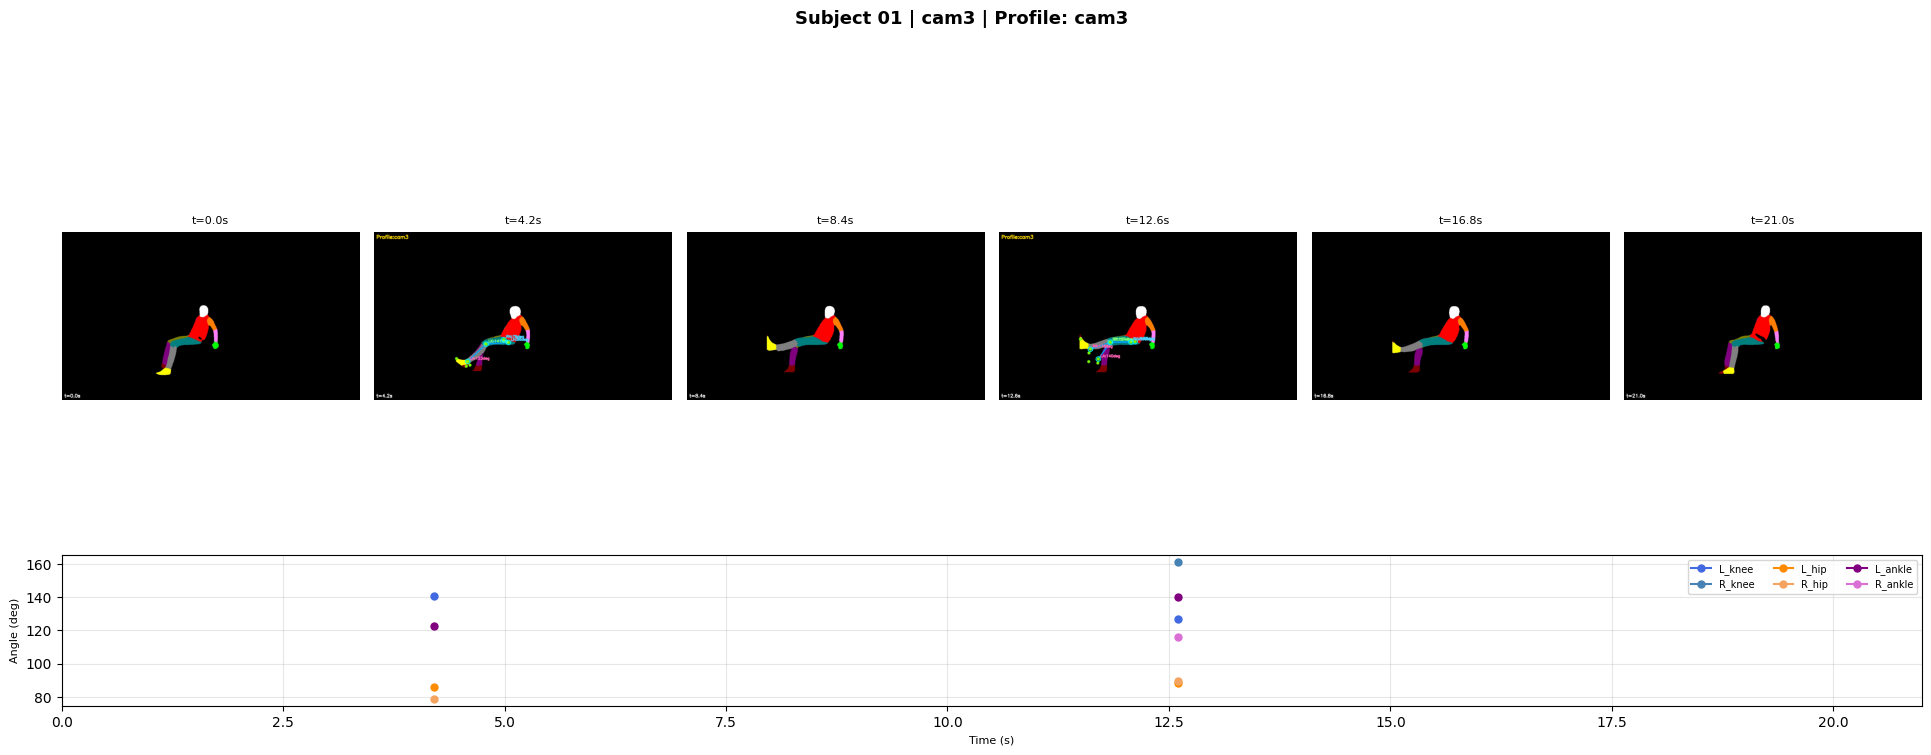

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frame_angles_cam3.png


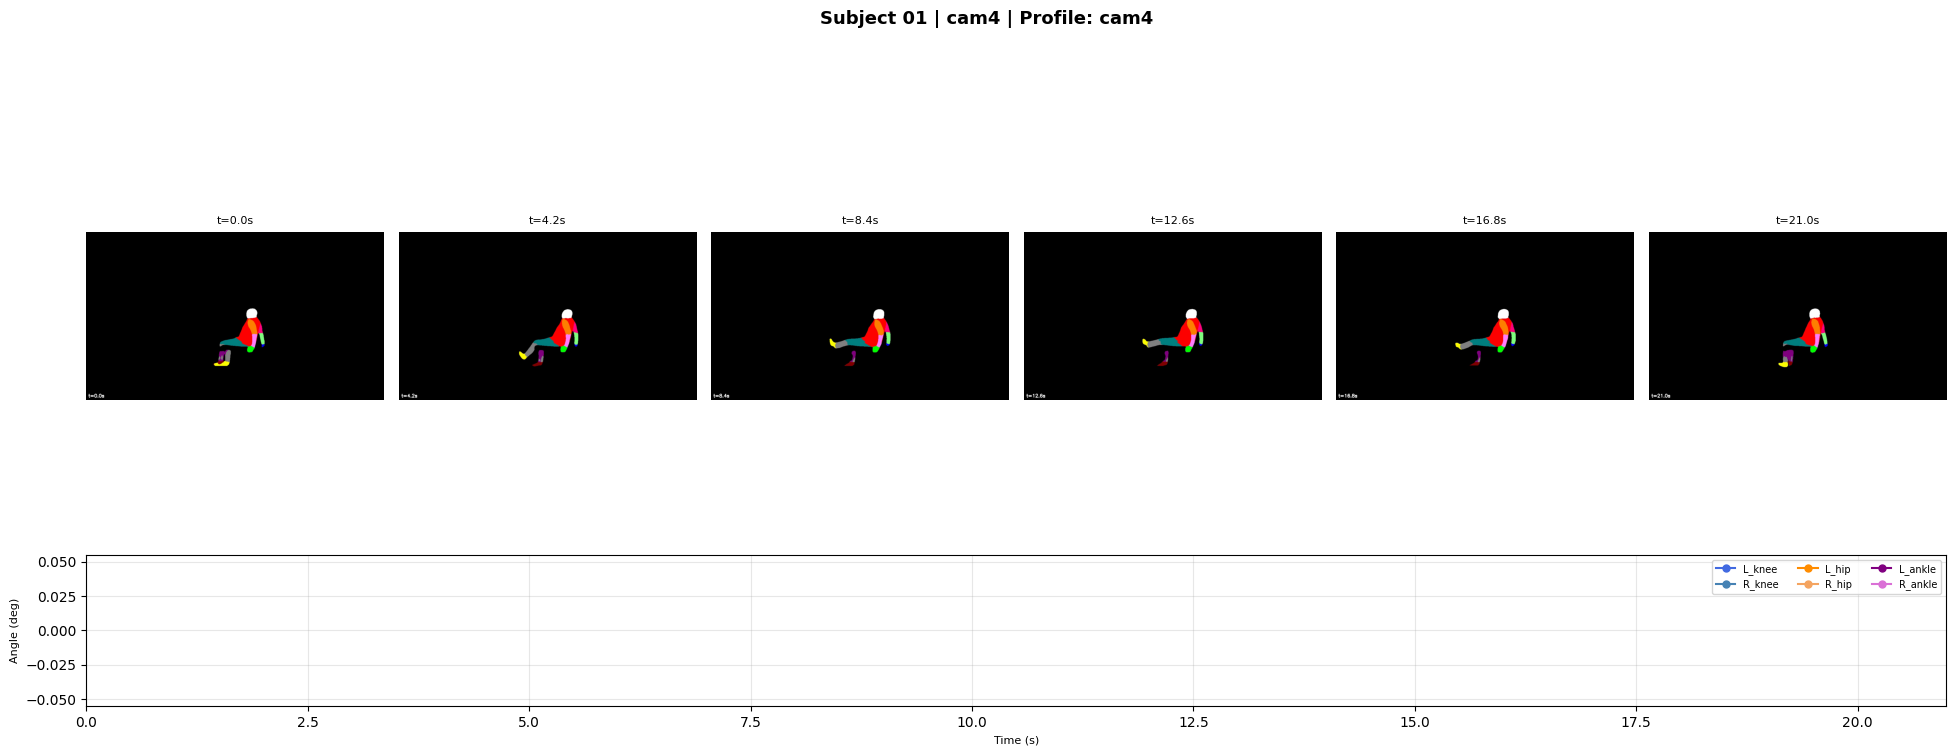

Saved: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles\subject_01\frame_angles_cam4.png


In [9]:
sidViz = subjectIds[0]
STRIP_FRAMES = 6   

with mpPose.Pose(static_image_mode=True, model_complexity=modelComplexity,
                 min_detection_confidence=minDetectConf) as poseS:
    for df in [d for d in allDfs if d['subject'].iloc[0] == sidViz]:
        cam     = df['camera'].iloc[0]
        profile = profileOf(cam)
        vidPath = videoFiles.get((sidViz, cam))
        if not vidPath: continue
        cap = cv2.VideoCapture(vidPath)
        nf  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

        strip_imgs, strip_ts, strip_angs = [], [], {}
        for k in ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']:
            strip_angs[k] = []

        for fi in [int(nf*i/(STRIP_FRAMES-1)) for i in range(STRIP_FRAMES)]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, min(fi, nf-1))
            ok, frm = cap.read()
            if not ok: continue
            h,w = frm.shape[:2]
            res = poseS.process(cv2.cvtColor(enhanceFrame(frm), cv2.COLOR_BGR2RGB))
            ang = {k: None for k in strip_angs}
            if res.pose_landmarks:
                lm = res.pose_landmarks.landmark
                def _p(i): p=lm[i]; return (int(p.x*w),int(p.y*h)) if p.visibility>=visibilityThresh else None
                LH,RH,LK,RK,LA,RA=_p(23),_p(24),_p(25),_p(26),_p(27),_p(28)
                LFI,RFI=_p(31),_p(32)
                if all([LH,LK,LA]):  ang['L_knee']=round(clip_angle('L_knee',angle(LH,LK,LA)),1)
                if all([RH,RK,RA]):  ang['R_knee']=round(clip_angle('R_knee',angle(RH,RK,RA)),1)
                if LH and LK:
                    th=np.array([LK[0]-LH[0],LK[1]-LH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['L_hip']=round(clip_angle('L_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1)))),1)
                if RH and RK:
                    th=np.array([RK[0]-RH[0],RK[1]-RH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['R_hip']=round(clip_angle('R_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1)))),1)
                if all([LK,LA,LFI]): ang['L_ankle']=round(clip_angle('L_ankle',angle(LK,LA,LFI)),1)
                if all([RK,RA,RFI]): ang['R_ankle']=round(clip_angle('R_ankle',angle(RK,RA,RFI)),1)
                drawAnglesOnFrame(frm, lm, ang, w, h, profile)
            for k in strip_angs: strip_angs[k].append(ang[k])
            ts_val = round(fi/fps, 2)
            cv2.putText(frm,f't={ts_val}s',(10,h-12),cv2.FONT_HERSHEY_SIMPLEX,0.65,(255,255,255),2)
            strip_imgs.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
            strip_ts.append(ts_val)
        cap.release()
        if not strip_imgs: continue

        n = len(strip_imgs)
        fig = plt.figure(figsize=(4*n, 8))
        gs  = fig.add_gridspec(2, n, height_ratios=[3,1], hspace=0.04, wspace=0.05)
        fig.suptitle(f'Subject {sidViz} | {cam} | Profile: {profile}', fontsize=13, fontweight='bold')

        for i, img in enumerate(strip_imgs):
            ax = fig.add_subplot(gs[0, i])
            ax.imshow(img); ax.axis('off')
            ax.set_title(f't={strip_ts[i]}s', fontsize=8)

        axB = fig.add_subplot(gs[1, :])
        colors = {'L_knee':'royalblue','R_knee':'steelblue',
                  'L_hip':'darkorange','R_hip':'sandybrown',
                  'L_ankle':'purple','R_ankle':'orchid'}
        for k, col in colors.items():
            vals = [v if v is not None else float('nan') for v in strip_angs[k]]
            axB.plot(strip_ts, vals, 'o-', color=col, lw=1.5, ms=5, label=k)
        axB.set_xlabel('Time (s)', fontsize=8); axB.set_ylabel('Angle (deg)', fontsize=8)
        axB.legend(ncol=3, fontsize=7, loc='upper right'); axB.grid(True, alpha=0.3)
        axB.set_xlim(strip_ts[0], strip_ts[-1])

        out = os.path.join(outputDir, f'subject_{sidViz}', f'frame_angles_{cam}.png')
        plt.savefig(out, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out}')


ROM 

In [10]:
aCols = ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']
DET_FLAG_WARN  = 0.50   
DET_FLAG_POOR  = 0.30   

rows  = []
for df in allDfs:
    det_rate = df['detection'].mean()
    if det_rate >= DET_FLAG_WARN:
        det_flag = 'ok'
    elif det_rate >= DET_FLAG_POOR:
        det_flag = 'low'
    else:
        det_flag = 'poor'
    r = {'subject':df['subject'].iloc[0],'camera':df['camera'].iloc[0],
         'det_%':f"{100*det_rate:.1f}",'det_flag':det_flag,'frames':len(df)}
    for c in aCols:
        s = df[c].dropna()
        n_valid = len(s)
        if n_valid == 0:
            r[f'{c}_mean'] = 'N/A'
            r[f'{c}_ROM']  = 'N/A'
            r[f'{c}_n']    = 0
        else:
            w = det_rate if det_flag != 'poor' else float('nan')
            r[f'{c}_mean']   = f'{s.mean():.1f}'
            r[f'{c}_ROM']    = f'{s.max()-s.min():.1f}'
            r[f'{c}_n']      = n_valid
            r[f'{c}_wtmean'] = f'{s.mean()*w:.1f}' if not isinstance(w, float) or not __import__("math").isnan(w) else 'unreliable'
    rows.append(r)
dfSummary = pd.DataFrame(rows)
dfSummary.to_csv(os.path.join(outputDir,'rom_summary.csv'), index=False)
display(dfSummary.head(20))

,subject,camera,det_%,det_flag,frames,L_knee_mean,L_knee_ROM,L_knee_n,L_knee_wtmean,R_knee_mean,...,R_hip_n,R_hip_wtmean,L_ankle_mean,L_ankle_ROM,L_ankle_n,L_ankle_wtmean,R_ankle_mean,R_ankle_ROM,R_ankle_n,R_ankle_wtmean
0,01,cam0,100.0,ok,630,136.5,83.4,630,136.5,113.6,...,568,85.0,116.8,44.9,630,116.8,127.0,41.2,479,127.0
1,01,cam1,100.0,ok,630,137.9,85.8,630,137.9,108.8,...,374,78.6,113.0,47.5,630,113.0,124.2,27.2,374,124.2
2,01,cam2,100.0,ok,630,133.9,84.3,630,133.9,106.2,...,434,85.4,116.1,41.0,630,116.1,126.5,40.1,408,126.5
3,01,cam3,100.0,ok,630,141.2,75.9,630,141.2,120.4,...,459,78.2,123.8,28.4,630,123.8,126.7,41.6,366,126.7
4,01,cam4,100.0,ok,630,130.3,91.9,630,130.3,114.8,...,453,79.1,104.6,52.5,630,104.6,129.0,30.6,276,129.0
5,02,cam0,99.9,ok,917,136.0,94.2,917,135.8,132.9,...,491,86.1,115.5,43.5,917,115.3,115.3,30.5,185,115.1
6,02,cam1,100.0,ok,917,133.9,88.2,917,133.9,125.3,...,448,82.1,109.4,40.6,917,109.4,117.6,25.3,240,117.6
7,02,cam2,100.0,ok,917,131.8,90.3,917,131.8,130.5,...,173,87.7,112.2,47.4,917,112.2,117.8,28.9,142,117.8
8,02,cam3,100.0,ok,917,135.3,83.3,917,135.3,150.7,...,874,84.2,119.7,38.8,917,119.7,119.9,32.8,398,119.9
9,02,cam4,100.0,ok,916,133.4,89.2,916,133.4,N/A,...,10,95.3,105.9,64.0,883,105.9,N/A,N/A,0,NaN
